In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("housing.csv")

In [3]:
data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [5]:
data.dropna(inplace=True)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20433 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20433 non-null  float64
 1   latitude            20433 non-null  float64
 2   housing_median_age  20433 non-null  float64
 3   total_rooms         20433 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20433 non-null  float64
 6   households          20433 non-null  float64
 7   median_income       20433 non-null  float64
 8   median_house_value  20433 non-null  float64
 9   ocean_proximity     20433 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.7+ MB


In [7]:
from sklearn.model_selection import train_test_split
x = data.drop(['median_house_value'],axis = 1)
y = data['median_house_value']

In [8]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2)

In [9]:
train_data = x_train.join(y_train)

In [10]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
4817,-118.29,34.04,48.0,1353.0,488.0,1945.0,487.0,2.4359,<1H OCEAN,123700.0
162,-122.24,37.81,52.0,2513.0,502.0,1048.0,518.0,3.6750,NEAR BAY,269900.0
7777,-118.10,33.91,35.0,1653.0,325.0,1072.0,301.0,3.2708,<1H OCEAN,159700.0
18585,-121.77,36.94,18.0,1063.0,341.0,1033.0,313.0,2.0192,<1H OCEAN,171300.0
5709,-118.23,34.21,32.0,1464.0,406.0,693.0,380.0,2.5463,<1H OCEAN,200000.0
...,...,...,...,...,...,...,...,...,...,...
11572,-118.01,33.76,26.0,2141.0,597.0,2038.0,585.0,2.2981,<1H OCEAN,177700.0
5244,-118.43,34.11,27.0,10806.0,1440.0,3511.0,1352.0,12.7296,<1H OCEAN,500001.0
13647,-117.31,34.08,40.0,2011.0,495.0,1528.0,469.0,1.9375,INLAND,69900.0
1921,-120.84,38.81,11.0,1280.0,286.0,609.0,248.0,3.1635,INLAND,132600.0


array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

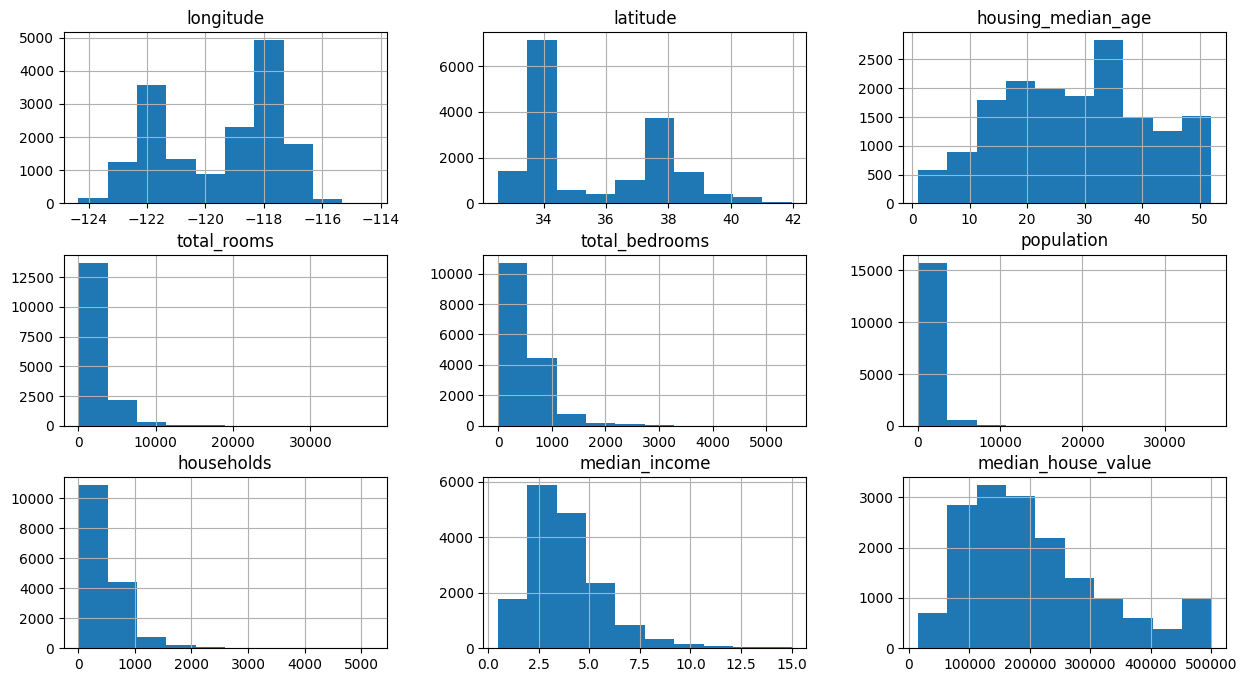

In [11]:
train_data.hist(figsize = (15,8))

<Axes: >

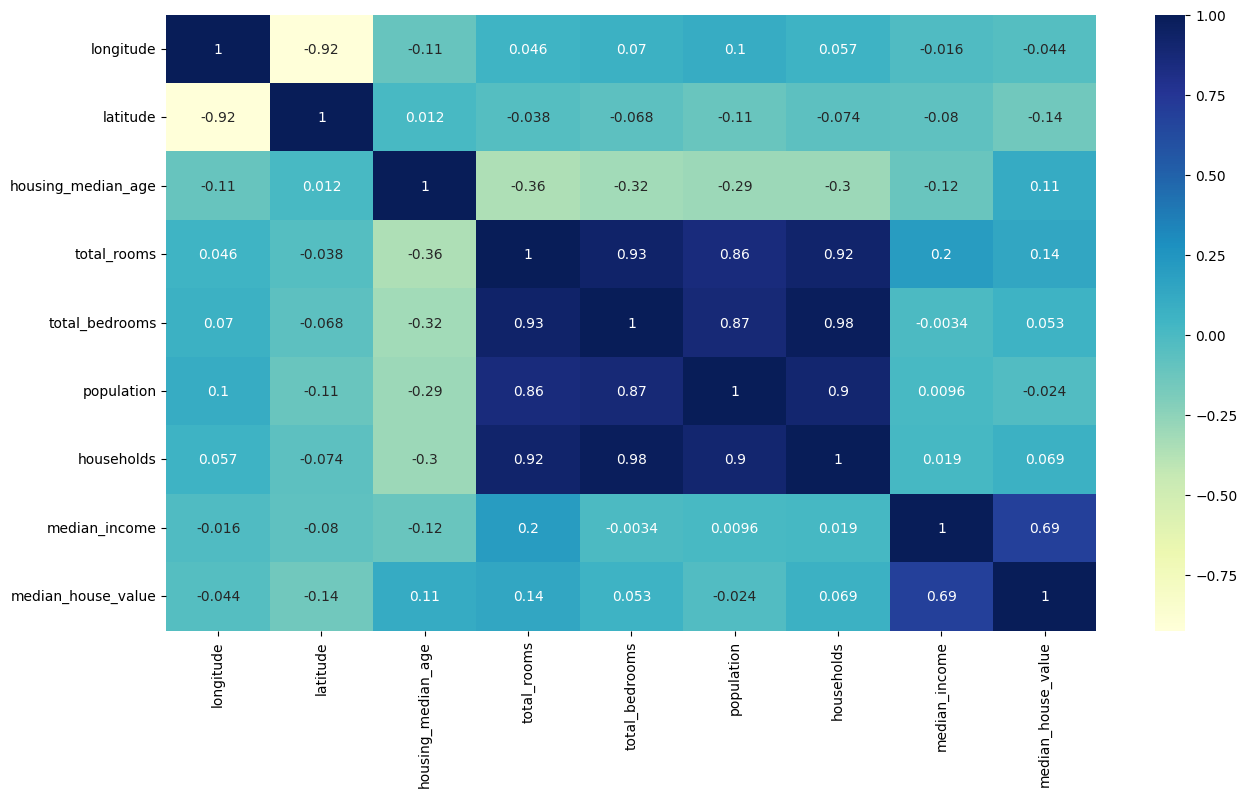

In [12]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),cmap = "YlGnBu",annot=True)

In [13]:
train_data['total_rooms'] = np.log(train_data['total_rooms']+1)
train_data['total_bedrooms'] = np.log(train_data['total_bedrooms']+1)
train_data['population'] = np.log(train_data['population']+1)
train_data['households'] = np.log(train_data['households']+1)

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

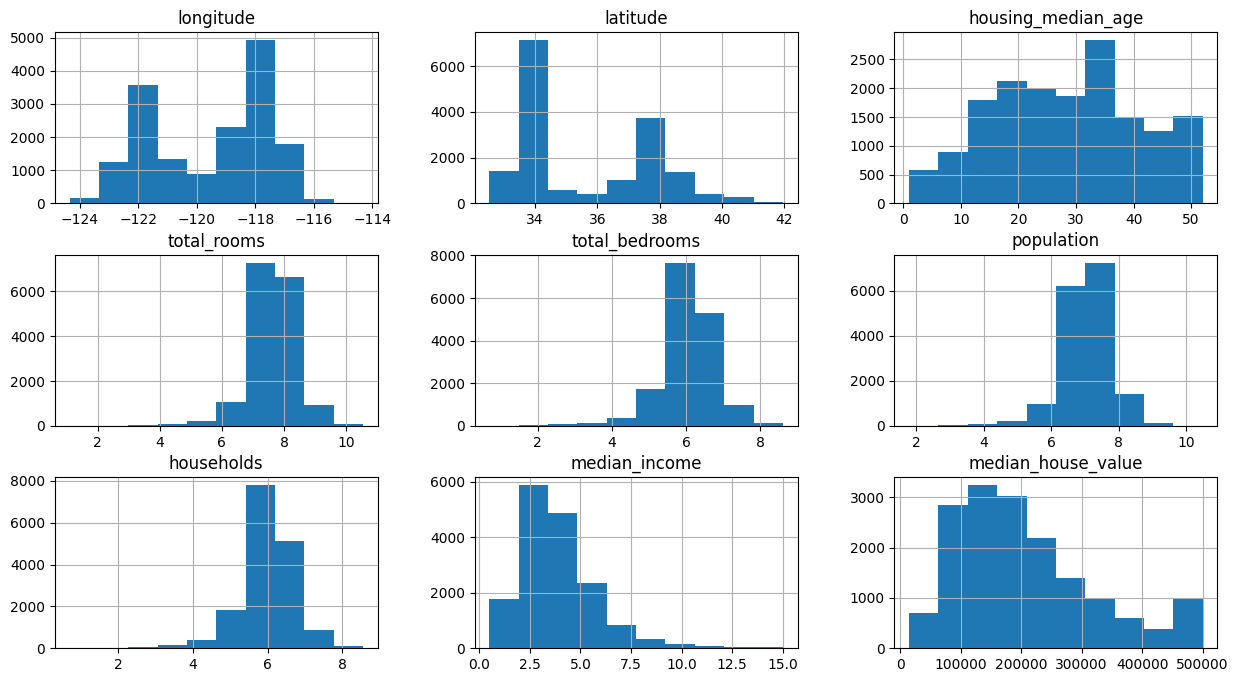

In [14]:
train_data.hist(figsize=(15,8))

In [15]:
train_data = train_data.join(pd.get_dummies(train_data['ocean_proximity'], dtype=int)).drop(['ocean_proximity'],axis = 1)

<Axes: >

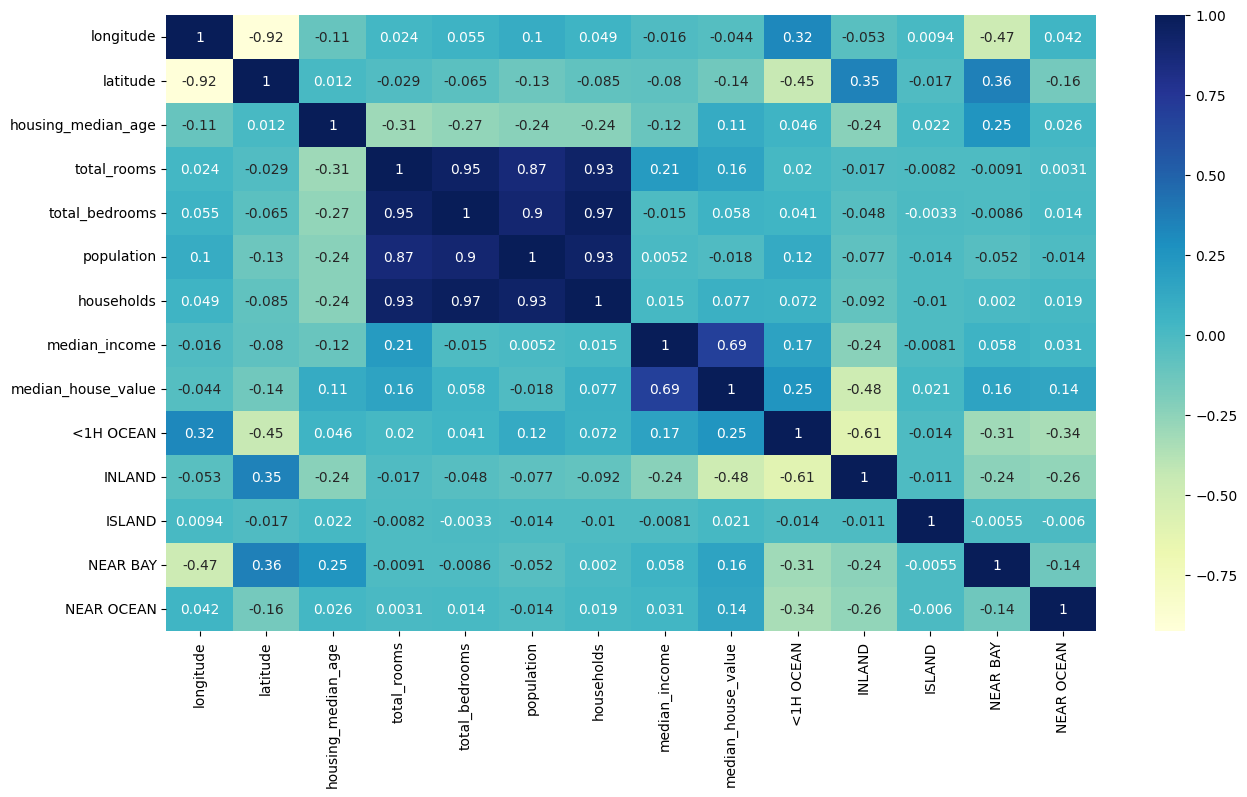

In [16]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),cmap = "YlGnBu",annot=True)

<Axes: xlabel='latitude', ylabel='longitude'>

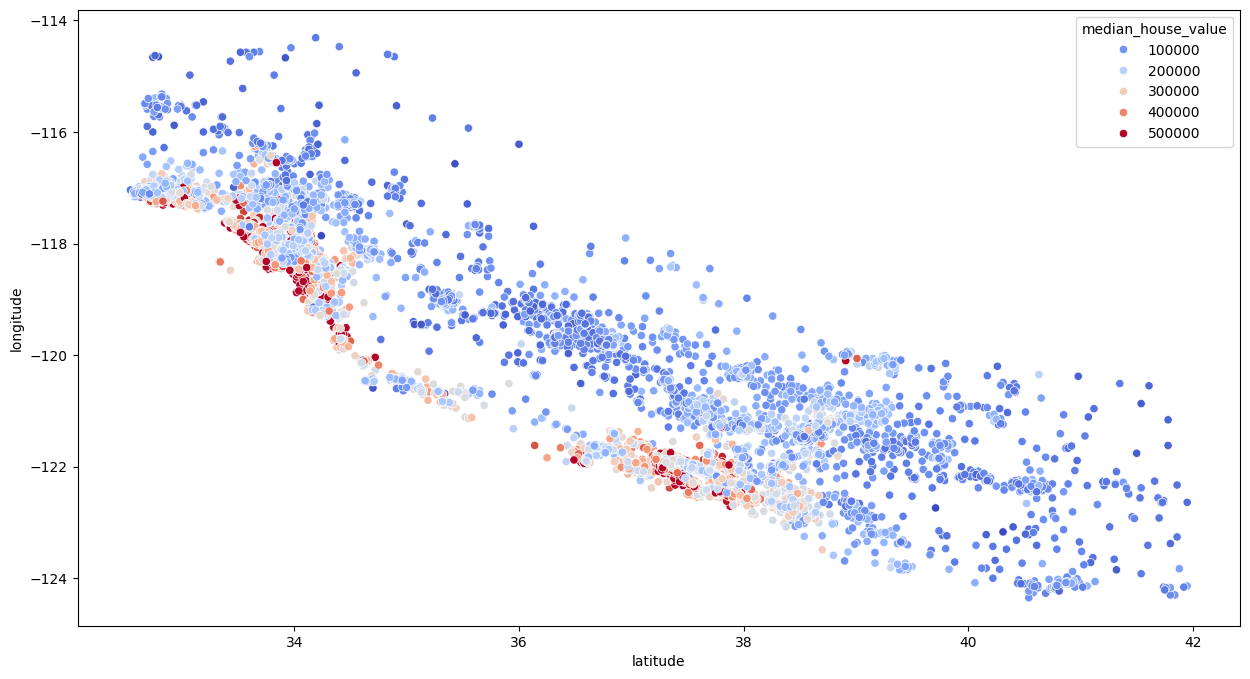

In [17]:
plt.figure(figsize=(15,8))
sns.scatterplot(y= "longitude",x="latitude",data=train_data,hue="median_house_value",palette="coolwarm")

In [18]:
train_data['bedroom_ratio'] = train_data['total_bedrooms'] / train_data['total_rooms'] 
train_data['household_rooms'] = train_data['total_rooms'] / train_data['households'] 

<Axes: >

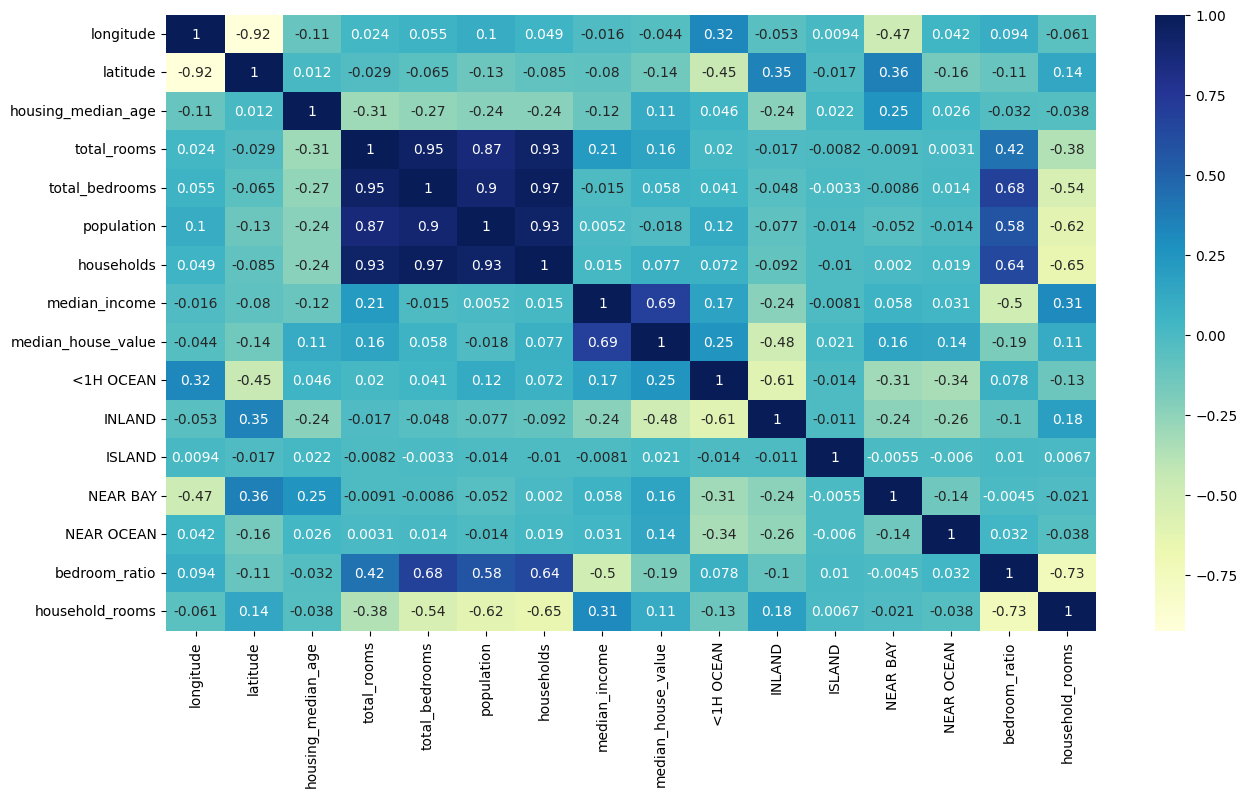

In [19]:
plt.figure(figsize=(15,8))
sns.heatmap(train_data.corr(numeric_only=True),cmap = "YlGnBu",annot=True)

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

scale = StandardScaler()

x_train,y_train = train_data.drop(['median_house_value'],axis = 1),train_data['median_house_value']
x_train_s = scale.fit_transform(x_train)
reg = LinearRegression()

reg.fit(x_train_s,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
test_data = x_test.join(y_test)

test_data['total_rooms'] = np.log(test_data['total_rooms']+1)
test_data['total_bedrooms'] = np.log(test_data['total_bedrooms']+1)
test_data['population'] = np.log(test_data['population']+1)
test_data['households'] = np.log(test_data['households']+1) 

test_data = test_data.join(pd.get_dummies(test_data['ocean_proximity'], dtype=int)).drop(['ocean_proximity'],axis = 1)

test_data['bedroom_ratio'] = test_data['total_bedrooms'] / test_data['total_rooms'] 
test_data['household_rooms'] = test_data['total_rooms'] / test_data['households']

In [22]:
x_test,y_test = test_data.drop(['median_house_value'],axis=1),test_data['median_house_value']

In [23]:
train_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
4817,-118.29,34.04,48.0,7.210818,6.192362,7.573531,6.190315,2.4359,123700.0,1,0,0,0,0,0.858760,1.164855
162,-122.24,37.81,52.0,7.829630,6.220590,6.955593,6.251904,3.6750,269900.0,0,0,0,1,0,0.794493,1.252359
7777,-118.10,33.91,35.0,7.410952,5.786897,6.978214,5.710427,3.2708,159700.0,1,0,0,0,0,0.780858,1.297793
18585,-121.77,36.94,18.0,6.969791,5.834811,6.941190,5.749393,2.0192,171300.0,1,0,0,0,0,0.837157,1.212265
5709,-118.23,34.21,32.0,7.289611,6.008813,6.542472,5.942799,2.5463,200000.0,1,0,0,0,0,0.824298,1.226629
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11572,-118.01,33.76,26.0,7.669495,6.393591,7.620215,6.373320,2.2981,177700.0,1,0,0,0,0,0.833639,1.203375
5244,-118.43,34.11,27.0,9.287949,7.273093,8.163941,7.210080,12.7296,500001.0,1,0,0,0,0,0.783068,1.288190
13647,-117.31,34.08,40.0,7.606885,6.206576,7.332369,6.152733,1.9375,69900.0,0,1,0,0,0,0.815916,1.236342
1921,-120.84,38.81,11.0,7.155396,5.659482,6.413459,5.517453,3.1635,132600.0,0,1,0,0,0,0.790939,1.296866


In [24]:
x_test_s = scale.transform(x_test)

In [25]:
test_data

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,<1H OCEAN,INLAND,ISLAND,NEAR BAY,NEAR OCEAN,bedroom_ratio,household_rooms
20621,-121.47,39.01,37.0,7.126891,5.513429,6.184149,5.062595,2.3661,77500.0,0,1,0,0,0,0.773609,1.407754
14003,-116.90,34.52,20.0,8.155362,6.734592,7.435438,6.376727,1.4000,77700.0,0,1,0,0,0,0.825787,1.278926
20416,-118.85,34.20,28.0,7.621195,5.697093,6.744059,5.638355,6.7612,323700.0,1,0,0,0,0,0.747533,1.351670
19373,-120.90,37.81,27.0,8.346168,6.621406,7.669962,6.616065,3.7031,173300.0,0,1,0,0,0,0.793347,1.261500
4579,-118.28,34.07,25.0,8.925720,8.064636,8.884887,7.973500,2.0173,177500.0,1,0,0,0,0,0.903528,1.119423
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2663,-123.75,40.11,35.0,7.627057,6.169611,6.803505,5.998937,1.9625,101500.0,1,0,0,0,0,0.808911,1.271402
757,-122.07,37.66,28.0,7.732369,6.415097,7.135687,6.376727,2.6719,161200.0,0,0,0,1,0,0.829642,1.212592
2348,-119.69,36.80,31.0,7.854381,6.129050,7.175490,6.037871,3.2813,68700.0,0,1,0,0,0,0.780335,1.300853
6055,-117.86,33.99,10.0,9.788133,7.942007,9.069583,7.888710,6.3875,310700.0,1,0,0,0,0,0.811391,1.240777


In [26]:
reg.score(x_test_s,y_test)

0.670102539302402

In [27]:
from sklearn.ensemble import RandomForestRegressor

forest = RandomForestRegressor()

forest.fit(x_train_s,y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
forest.score(x_test_s,y_test)

0.8194293273529737

In [41]:
from sklearn.model_selection import GridSearchCV

forest = RandomForestRegressor()

param_grid = {
    "n_estimators" : [100,200,250],
    "min_samples_split" : [2,4],
    "max_depth" : [None,4,8]
}

grid_search = GridSearchCV(forest,param_grid,cv=5,
                          scoring = "neg_mean_squared_error",
                           return_train_score=True)

grid_search.fit(x_train_s,y_train)

,estimator,RandomForestRegressor()
,param_grid,"{'max_depth': [None, 4, ...], 'min_samples_split': [2, 4], 'n_estimators': [100, 200, ...]}"
,scoring,'neg_mean_squared_error'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,True
,n_estimators,200


In [42]:
best_forest = grid_search.best_estimator_

In [43]:
best_forest.score(x_test_s,y_test)

0.8199014338886857